In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Salary_dataset.csv to Salary_dataset (1).csv


In [9]:
df = pd.read_csv(list(uploaded.keys())[0])

In [10]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [11]:
df.shape

(30, 3)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [13]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [15]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64


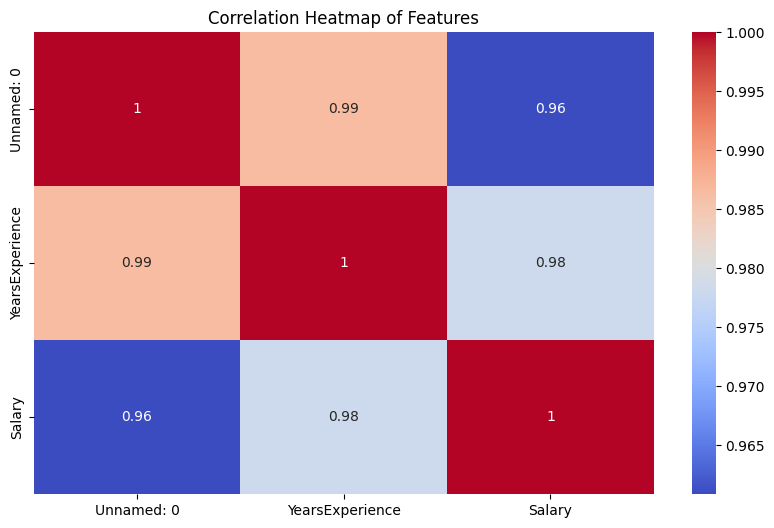

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

In [28]:
x = df[['YearsExperience']]
y = df['Salary']

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [30]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [31]:
print(x_train_scaled.shape)
print(x_test_scaled.shape)

(24, 1)
(6, 1)


In [32]:
print(x_train_scaled)

[[ 1.77445774]
 [ 1.21912622]
 [-0.41216011]
 [-1.41869849]
 [-1.03690807]
 [-0.03036969]
 [-0.79395053]
 [-0.37745189]
 [-0.41216011]
 [ 0.94146047]
 [-1.34928205]
 [-1.27986561]
 [ 1.32325088]
 [-1.10632451]
 [ 0.66379471]
 [ 1.49679198]
 [ 0.24729607]
 [ 1.84387418]
 [ 0.55967005]
 [-0.68982587]
 [-0.44686833]
 [-0.23861901]
 [ 0.28200429]
 [-0.75924231]]


In [33]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

LinearRegression()

In [34]:
y_pred = model.predict(x_test_scaled)

In [38]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nIntercept:", model.intercept_)
print("\nCoefficients:", model.coef_)
print("Mean Squarded Error:", mse)
print("R² Score:", r2)


Intercept: 74208.625

Coefficients: [27151.53742583]
Mean Squarded Error: 49830096.85590836
R² Score: 0.9024461774180498


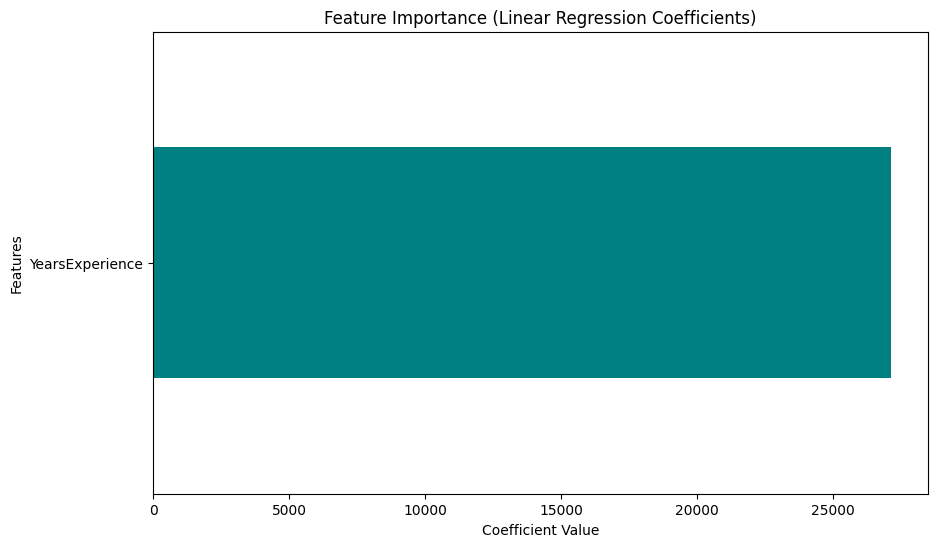

In [41]:
feature_importance = pd.Series(model.coef_, index=x.columns)
plt.figure(figsize=(10,6))
feature_importance.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.show()

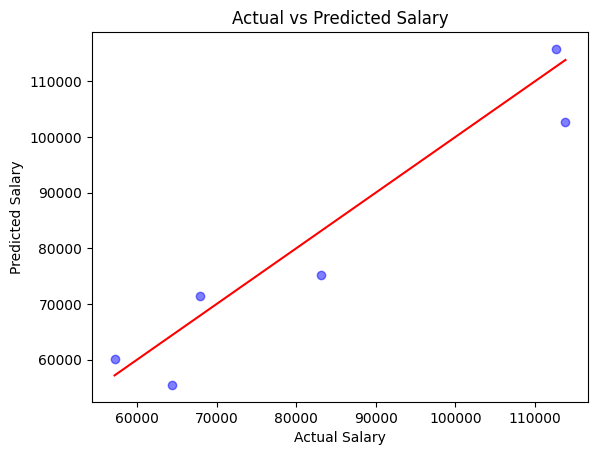

In [47]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.show()

In [46]:
sample_input = np.array([[8]])
sample_input_scaled = scaler.transform(sample_input)

predicted_value = model.predict(sample_input_scaled)[0]
print(f"\nPredicted Salary: ${predicted_value}")


Predicted Salary: $99770.72406372151


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
